1. Impot Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

2. Load Dataset

In [4]:
df = pd.read_csv('creditcard.csv')

print("===== DATASET AWAL =====")
print(df.head())

print("\n===== INFORMASI DATASET =====")
print(df.info())

print("\nJumlah baris & kolom:", df.shape)

===== DATASET AWAL =====
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

       

## 3. Exploratory Data Analysis (EDA) Singkat


--- Nilai Kosong ---
0

--- Distribusi Kelas ---
Class
0    284315
1       492
Name: count, dtype: int64


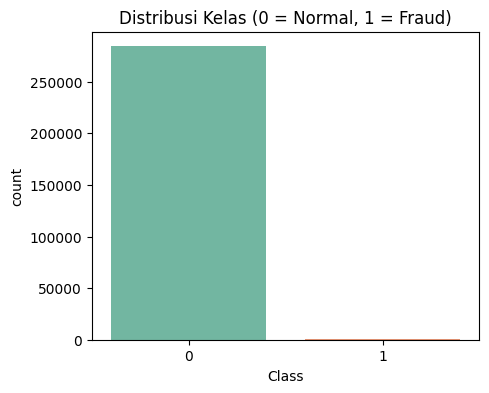

In [5]:
print("\n--- Nilai Kosong ---")
print(df.isnull().sum().sum())

print("\n--- Distribusi Kelas ---")
print(df['Class'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title("Distribusi Kelas (0 = Normal, 1 = Fraud)")
plt.show()

4. Preprocessing


Normalisasi kolom Amount & Time

In [6]:
scaler = StandardScaler()
df['norm_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['norm_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Amount','Time'], axis=1, inplace=True)

Split data

In [7]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nSebelum SMOTE:")
print(y_train.value_counts())


Sebelum SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64


5.  Tangani Imbalance Data (SMOTE)

In [8]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSetelah SMOTE:")
print(y_train_smote.value_counts())


Setelah SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


6. Definisikan Model

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

7. Training & Evaluasi

In [12]:
RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

8. Bandingkan Hasil Model


--- Ringkasan Evaluasi Model ---
                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression    0.05814  0.918367  0.109356  0.969848


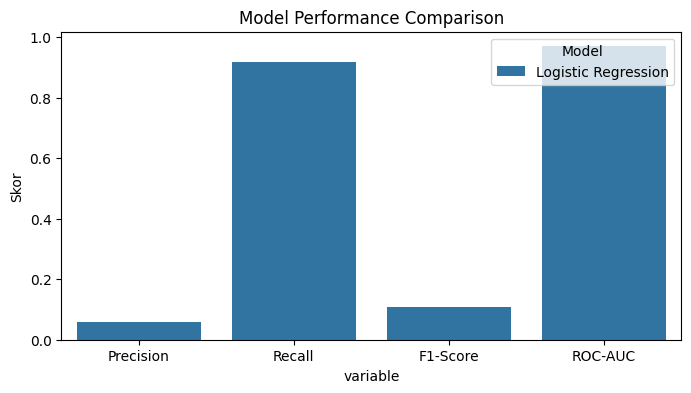

In [17]:
results_df = pd.DataFrame(results)
print("\n--- Ringkasan Evaluasi Model ---")
print(results_df)

plt.figure(figsize=(8,4))
sns.barplot(data=results_df.melt(id_vars='Model', value_vars=['Precision','Recall','F1-Score','ROC-AUC']),
            x='variable', y='value', hue='Model')
plt.title("Model Performance Comparison")
plt.ylabel("Skor")
plt.show()


9. Confusion Matrix

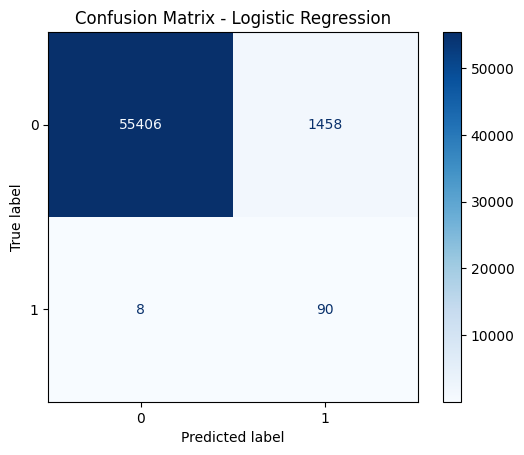

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = results_df.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


10. Analisis Singkat

In [16]:
print(f"\nModel terbaik berdasarkan ROC-AUC: {best_model_name}")


Model terbaik berdasarkan ROC-AUC: Logistic Regression
